In [10]:
import numpy as np

In [11]:

Wc = 0.01
m=10
delta_z=1
dz=0.01
mu_a=20
mu_z=1
N=100000

for i in range(1, N+1):
    z=0
    W=1
    A=0
    while W != 0:
        rng = np.random.default_rng()
        e_1 = rng.uniform(0, 1)
        L=-np.log(e_1)/mu_a # Distance de parcours
        z+= mu_z*L  # Propagation
        delta_W = -mu_a*W
        A+=delta_W
        W-=delta_W   # Absorption
        if W<Wc:
            e_4 = rng.uniform(0, 1)
            if e_4 <= 1/m:
                W*=m
            else :
                W=0








KeyboardInterrupt: 

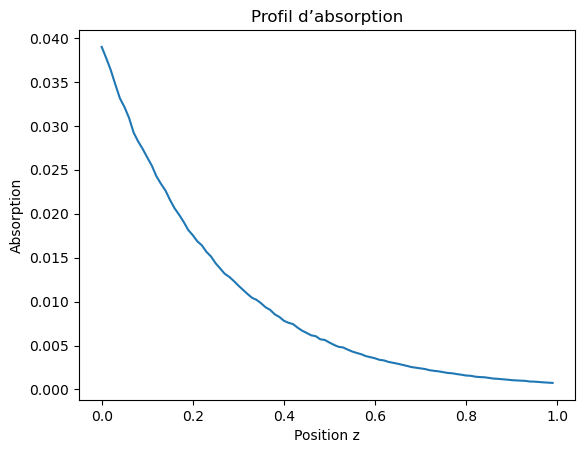

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Wc = 0.01
m = 10
delta_z = 1
dz = 0.01
mu_a = 20
mu_z = 1
N = 100000

z_axis = np.arange(0, delta_z, dz)
absorption = np.zeros(len(z_axis))

rng = np.random.default_rng()

for i in range(N):

    z = 0
    W = 1

    while W > 0 and z < delta_z:

        e_1 = rng.uniform()
        L = -np.log(e_1) / mu_a
        z += mu_z * L

        delta_W = mu_a * W * dz   # absorption locale

        voxel = int(z / dz)

        if voxel < len(absorption):
            absorption[voxel] += delta_W

        W -= delta_W

        if W < Wc:
            if rng.uniform() <= 1/m:
                W *= m
            else:
                W = 0

absorption /= N

plt.plot(z_axis, absorption)
plt.xlabel("Position z")
plt.ylabel("Absorption")
plt.title("Profil d’absorption")
#plt.yscale("log")
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# paramètres
Nphotons = 100000
Wc = 0.01
m = 10

mu_a = 20   # mm^-1

L = 2.0  # mm taille du cube
Nx = Ny = Nz = 100

dx = dy = dz = L / Nx

# volume d'absorption
A = np.zeros((Nx, Ny, Nz))

rng = np.random.default_rng()

for i in range(Nphotons):

    x = Nx // 2
    y = Ny // 2
    z = 0

    W = 1.0

    z_pos = 0.0

    while W > 0 and z_pos < L:

        # distance libre
        s = -np.log(rng.uniform()) / mu_a

        z_pos += s

        iz = int(z_pos / dz)

        if iz >= Nz:
            break

        # absorption locale
        deltaW = mu_a * W * dz

        A[x, y, iz] += deltaW

        W -= deltaW

        # roulette russe
        if W < Wc:
            if rng.uniform() <= 1/m:
                W *= m
            else:
                W = 0

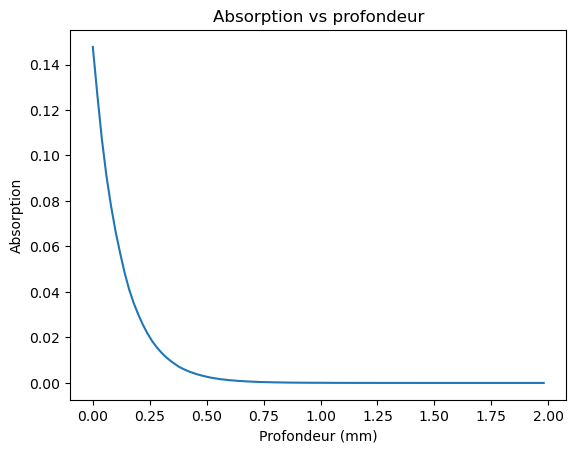

In [14]:
depth_abs = np.sum(A, axis=(0,1)) / Nphotons

z_axis = np.arange(Nz) * dz

plt.figure()
plt.plot(z_axis, depth_abs)
#plt.yscale("log")
plt.xlabel("Profondeur (mm)")
plt.ylabel("Absorption")
plt.title("Absorption vs profondeur")
plt.show()

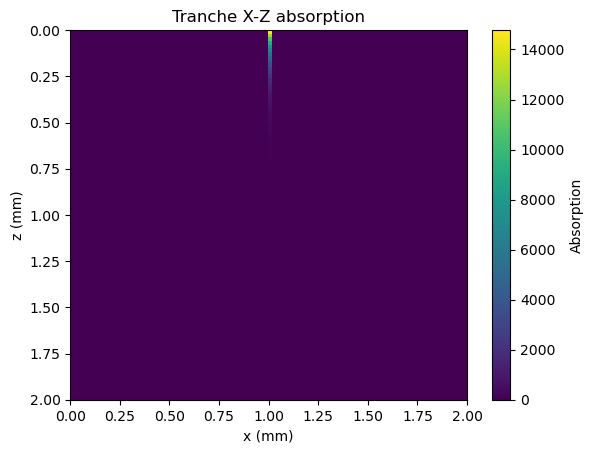

In [15]:
plt.figure()
plt.imshow(A[:, Ny//2, :].T,
           extent=[0, L, L, 0],
           aspect='auto')

plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title("Tranche X-Z absorption")
plt.colorbar(label="Absorption")
plt.show()